In [15]:
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series >= lower) & (series <= upper)]

Max time model:
Metamodel: CssExtDsl, Model: result0_1000000, Time: 832.2020 s

Max memory model:
Metamodel: esb, Model: result0_1000000, Memory: 5.3797 GB


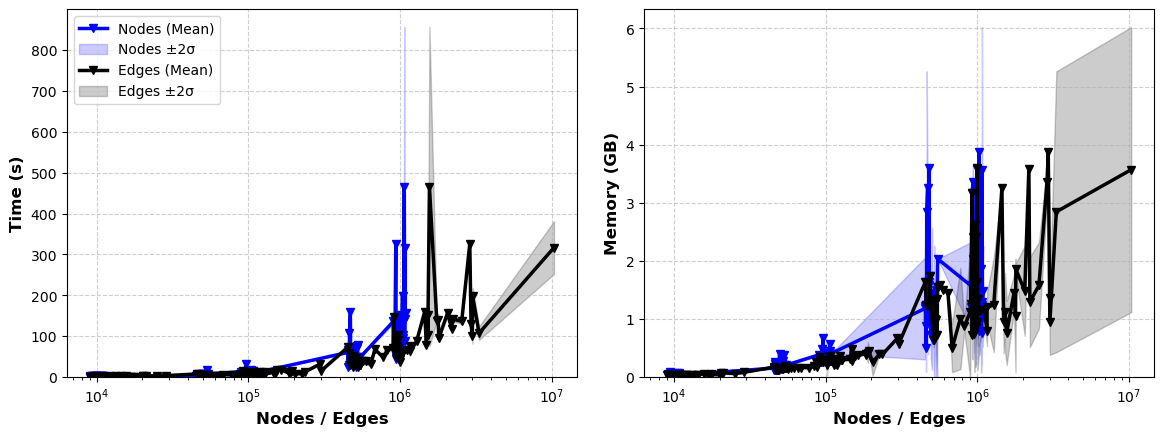

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

# ---- Helper (you already use it, keeping it here for completeness) ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]

# Load all run files from subfolders (one folder per metamodel)
run_files = glob.glob('../results/RQ2Models/**/run_*.csv', recursive=True)

dfs = []
for f in run_files:
    df = pd.read_csv(f)

    # Extract metamodel name from folder
    metamodel = os.path.basename(os.path.dirname(f))
    df['metamodel'] = metamodel

    # Convert units
    df['time'] = df['time'] / 1000.0          # ms → seconds
    df['mem'] = df['mem'] / (1024 * 1024)     # KB → GB

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# ---- PRINT MAX RESULTS ----
# Max time
idx_time = combined_df['time'].idxmax()
row_time = combined_df.loc[idx_time]
print("Max time model:")
print(f"Metamodel: {row_time['metamodel']}, Model: {row_time['model']}, Time: {row_time['time']:.4f} s")

# Max memory
idx_mem = combined_df['mem'].idxmax()
row_mem = combined_df.loc[idx_mem]
print("\nMax memory model:")
print(f"Metamodel: {row_mem['metamodel']}, Model: {row_mem['model']}, Memory: {row_mem['mem']:.4f} GB")

# ---- PLOTTING ----
props = ['nodes', 'edges']
colors = {'nodes': 'blue', 'edges': 'black'}
g = 2  # number of std deviations

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('')

# ---- TIME PLOT ----
for prop in props:
    grouped = combined_df.groupby(prop)['time']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[0].plot(
        mean.index, mean.values,
        color=colors[prop], linewidth=2.5, marker='v',
        label=f'{prop.capitalize()} (Mean)'
    )
    axes[0].fill_between(
        mean.index, lower, upper,
        color=colors[prop], alpha=0.2,
        label=f'{prop.capitalize()} ±{g}σ'
    )

axes[0].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Time (s)", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=10, frameon=True)
axes[0].set_xscale('log')

# ---- MEMORY PLOT ----
for prop in props:
    grouped = combined_df.groupby(prop)['mem']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[1].plot(
        mean.index, mean.values,
        color=colors[prop], linewidth=2.5, marker='v',
        label=f'{prop.capitalize()} (Mean)'
    )
    axes[1].fill_between(
        mean.index, lower, upper,
        color=colors[prop], alpha=0.2,
        label=f'{prop.capitalize()} ±{g}σ'
    )

axes[1].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Memory (GB)", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_ylim(bottom=0)
axes[1].set_xscale('log')

plt.tight_layout(pad=2)
plt.savefig("img/RQ2nodesedges.pdf", format='pdf', bbox_inches='tight')
plt.show()